In [1]:
# ===============================
# 📦 Standard Libraries
# ===============================
import os
import numpy as np
from glob import glob
from PIL import Image
import matplotlib.pyplot as plt
from scipy.io import loadmat

# ===============================
# 🔥 PyTorch Core
# ===============================
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter
from torch.nn.utils import clip_grad_norm_
from torch.optim.lr_scheduler import ReduceLROnPlateau, StepLR
from torchsummary import summary

# ===============================
# 🎨 torchvision
# ===============================
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder


# Dataset Preparation

In [2]:
# === Load dataset with .mat parsing ===
class ShanghaiDataset(Dataset):
    def __init__(self, image_dir, gt_dir, transform=None, return_raw=False):
        self.image_paths = sorted(glob(os.path.join(image_dir, '*.jpg')))
        self.gt_paths = sorted(glob(os.path.join(gt_dir, 'GT_*.mat')))
        self.transform = transform
        self.return_raw = return_raw

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        raw_image = image.copy()  # keep for visualization

        if self.transform:
            image = self.transform(image)

        gt = loadmat(self.gt_paths[idx])
        count = len(gt['image_info'][0, 0][0, 0][0])

        if self.return_raw:
            return image, torch.tensor([count], dtype=torch.float32), raw_image
        else:
            return image, torch.tensor([count], dtype=torch.float32)

## Data Augmentation Transforms

In [3]:
# === Augment-heavy Train Transform ===
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)
    ], p=0.8),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# === Clean Test Transform ===
test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


## Load Dataset

In [4]:
def custom_collate_fn(batch):
    imgs, targets, raws = zip(*batch)  # unzip the list of tuples
    return torch.stack(imgs), torch.stack(targets), raws

In [5]:
# === Dataloader ===
dataset_root = "/home/wins057/Documents/Projects/python-for-dl-homework/week10/dataset/ShanghaiTech_Crowd_Counting_Dataset"
# ShanghaiTech Part A
train_images = os.path.join(dataset_root, "part_A_final/train_data/images")
train_ground_truth = os.path.join(dataset_root, "part_A_final/train_data/ground_truth")
test_images = os.path.join(dataset_root, "part_A_final/test_data/images")
test_ground_truth = os.path.join(dataset_root, "part_A_final/test_data/ground_truth")

# Create dataset and dataloader
trainset = ShanghaiDataset(train_images, train_ground_truth, train_transform)
train_loader = DataLoader(trainset, batch_size=16, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
testset = ShanghaiDataset(test_images, test_ground_truth, test_transform, return_raw=True)
test_loader = DataLoader(testset, batch_size=1, shuffle=False, collate_fn=custom_collate_fn, num_workers=4, pin_memory=True, persistent_workers=True)

# Train and test dataset sizes
print("Train samples:", len(train_loader.dataset))
print("Test samples:", len(test_loader.dataset))

Train samples: 300
Test samples: 182


# Model Definitions

In [6]:
from torchvision.models import (
    efficientnet_b0, EfficientNet_B0_Weights,
    resnet18, ResNet18_Weights,
    mobilenet_v2, MobileNet_V2_Weights,
    shufflenet_v2_x0_5, ShuffleNet_V2_X0_5_Weights,
    mobilenet_v3_small, MobileNet_V3_Small_Weights,
    mnasnet0_5, MNASNet0_5_Weights
)

# Mapping between model names and their constructors + final layer names
model_configs = {
    'efficientnet_b0': (efficientnet_b0, EfficientNet_B0_Weights.DEFAULT, 'classifier'),
    'resnet18': (resnet18, ResNet18_Weights.DEFAULT, 'fc'),
    'mobilenet_v2': (mobilenet_v2, MobileNet_V2_Weights.DEFAULT, 'classifier'),
    'shufflenet_v2_x0_5': (shufflenet_v2_x0_5, ShuffleNet_V2_X0_5_Weights.DEFAULT, 'fc'),
    'mobilenet_v3_small': (mobilenet_v3_small, MobileNet_V3_Small_Weights.DEFAULT, 'classifier'),
    'mnasnet0_5': (mnasnet0_5, MNASNet0_5_Weights.DEFAULT, 'classifier')
}

def get_model(name):
    if name not in model_configs:
        raise ValueError(f"Model '{name}' is not supported.")
    
    constructor, weights, head = model_configs[name]
    model = constructor(weights=weights)

    if head == 'classifier':
        if name == 'efficientnet_b0':
            model.classifier[-1] = nn.Sequential(
                nn.Dropout(0.3),
                nn.Linear(model.classifier[-1].in_features, 1)
            )
        else:
            model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, 1)
    elif head == 'fc':
        model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.fc.in_features, 1)
        )

    return model

# Training Utilities

In [7]:
def save_checkpoint(model, optimizer, epoch, path):
    torch.save({
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "epoch": epoch
    }, path)

In [8]:
def count_parameters(model):
    """ Count the number of trainable parameters in the model.
    Args:
        model (nn.Module): The model to count parameters for.
    Returns:
        int: The number of trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [9]:
def mixup_data(x, y, alpha=0.4):
    '''Apply MixUp to a batch of images and labels'''
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    mixed_y = lam * y_a + (1 - lam) * y_b
    return mixed_x, mixed_y

In [10]:
def calculate_accuracy(mae, avg_gt):
    '''Calculate pseudo-accuracy based on MAE and average ground truth.'''
    return max(0, (1 - (mae / avg_gt)) * 100)

In [11]:
def calculate_avg_ground_truth(loader):
    """Calculate average ground truth (count) from a DataLoader.

    Supports both:
    - Train loader (batch: images, targets)
    - Test loader (batch: images, targets, raw images)
    """
    total = 0.0
    count = 0

    for batch in loader:
        # If batch has 3 elements (img, target, raw_img)
        if isinstance(batch, (tuple, list)) and len(batch) == 3:
            _, targets, _ = batch
        else:
            _, targets = batch

        total += targets.sum().item()
        count += targets.size(0)

    return total / count if count > 0 else 0


In [12]:
from torchinfo import summary
from ptflops import get_model_complexity_info
import torch

def summarize_model(model, input_size=(3, 256, 256)):
    """
    Prints a clean summary of model structure, parameters, and FLOPS (GFLOPS).
    Also returns (gflops, params_million).
    
    Args:
        model (nn.Module): PyTorch model
        input_size (tuple): (C, H, W)

    Returns:
        gflops (float): GFLOPS
        params_million (float): Total params in million
    """
    model = model.cpu()
    model.eval()

    print("\n🧠 Model Structure Summary:")
    info = summary(model, input_size=(1, *input_size), depth=2, col_names=["input_size", "output_size", "num_params"], verbose=0)
    print(info)
    print("\n📏 Calculating Params and FLOPS...")
    macs, params = get_model_complexity_info(
        model, 
        input_res=input_size, 
        as_strings=False, 
        print_per_layer_stat=False, 
        verbose=False
    )

    gflops = macs / 1e9
    params_million = params / 1e6

    print(f"\n📊 Total Parameters: {params_million:.2f} Million")
    print(f"⚡ Estimated Multiply-Adds (MACs): {gflops:.4f} GFLOPS\n")

    return gflops, params_million

In [ ]:
class TrainConfig:
    def __init__(self,
                 model_name="efficientnet_b0",
                 num_epochs=150,
                 lr=0.001,
                 patience=30,
                 ckpt_dir="checkpoints",
                 log_dir="runs/train",
                 use_mixup=True,
                 mixup_alpha=0.4,
                 use_grad_clip=True,
                 grad_clip_max_norm=1.0,
                 scheduler_type="reduce_plateau",
                 scheduler_factor=0.5,
                 scheduler_patience=5):
        
        self.model_name = model_name
        self.num_epochs = num_epochs
        self.lr = lr
        self.patience = patience
        self.ckpt_dir = ckpt_dir
        self.log_dir = log_dir
        
        # MixUp
        self.use_mixup = use_mixup
        self.mixup_alpha = mixup_alpha
        
        # Gradient Clipping
        self.use_grad_clip = use_grad_clip
        self.grad_clip_max_norm = grad_clip_max_norm
        
        # Scheduler
        self.scheduler_type = scheduler_type
        self.scheduler_factor = scheduler_factor
        self.scheduler_patience = scheduler_patience

# Main Training Function

In [14]:
from torch.optim.lr_scheduler import OneCycleLR

def train_model(config: TrainConfig):
    """
    Full training loop with MixUp, Gradient Clipping, AdamW, and One-Cycle LR scheduling.

    Args:
        config (TrainConfig): Configuration object containing all hyperparameters and paths.
    """
    # Setup device, directories, and TensorBoard
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    os.makedirs(config.ckpt_dir, exist_ok=True)
    writer = SummaryWriter(log_dir=config.log_dir)

    # Model initialization & graph logging
    model = get_model(config.model_name).to(device)
    dummy_input = torch.randn(1, 3, 256, 256, device=device)
    writer.add_graph(model, dummy_input)

    # Loss, optimizer, and One-Cycle scheduler
    criterion = nn.SmoothL1Loss(beta=1.0)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=1e-4)
    total_steps = config.num_epochs * len(train_loader)
    scheduler = OneCycleLR(
        optimizer,
        max_lr=config.lr,
        total_steps=total_steps,
        pct_start=0.1,
        anneal_strategy='cos'
    )

    # Tracking variables
    best_val_mae = float('inf')
    best_epoch = 0
    epochs_no_improve = 0

    # Precompute average ground truths for accuracy calculation
    avg_gt_train = calculate_avg_ground_truth(train_loader)
    avg_gt_val = calculate_avg_ground_truth(test_loader)
    print(f"Avg GT (Train): {avg_gt_train:.2f}  |  Avg GT (Val): {avg_gt_val:.2f}")

    # Main training loop
    for epoch in range(1, config.num_epochs + 1):
        model.train()
        train_mae_sum = 0.0

        for imgs, targets in train_loader:
            imgs, targets = imgs.to(device), targets.to(device)

            # MixUp augmentation
            if config.use_mixup and np.random.rand() < 0.5:
                imgs, targets = mixup_data(imgs, targets, alpha=config.mixup_alpha)

            preds = model(imgs).view(-1)
            loss = criterion(preds, targets.view(-1))

            optimizer.zero_grad()
            loss.backward()

            # Gradient clipping
            if config.use_grad_clip:
                clip_grad_norm_(model.parameters(), max_norm=config.grad_clip_max_norm)

            optimizer.step()
            scheduler.step()

            train_mae_sum += torch.abs(preds - targets.view(-1)).sum().item()

        train_mae = train_mae_sum / len(train_loader.dataset)

        # Validation phase
        model.eval()
        val_mae_sum = 0.0
        with torch.no_grad():
            for imgs, targets, _ in test_loader:
                imgs, targets = imgs.to(device), targets.to(device)
                preds = model(imgs).view(-1)
                val_mae_sum += torch.abs(preds - targets.view(-1)).sum().item()

        val_mae = val_mae_sum / len(test_loader.dataset)
        train_acc = calculate_accuracy(train_mae, avg_gt_train)
        val_acc = calculate_accuracy(val_mae, avg_gt_val)

        # Logging to TensorBoard
        writer.add_scalar(f"{config.model_name}/Train_MAE", train_mae, epoch)
        writer.add_scalar(f"{config.model_name}/Val_MAE", val_mae, epoch)
        writer.add_scalar(f"{config.model_name}/Train_Acc", train_acc, epoch)
        writer.add_scalar(f"{config.model_name}/Val_Acc", val_acc, epoch)

        log_msg = (
            f"[{config.model_name}] Epoch {epoch}/{config.num_epochs} | "
            f"Train MAE: {train_mae:.2f} ({train_acc:.2f}% Acc) | "
            f"Val MAE: {val_mae:.2f} ({val_acc:.2f}% Acc) | "
            f"LR: {optimizer.param_groups[0]['lr']:.1e}"
        )

        # Checkpoint & early stopping
        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_epoch = epoch
            epochs_no_improve = 0
            path = os.path.join(config.ckpt_dir, f"{config.model_name}_best.pth")
            save_checkpoint(model, optimizer, epoch, path)
            log_msg += " ✅ Saved"
        else:
            epochs_no_improve += 1

        print(log_msg)
        if epochs_no_improve >= config.patience:
            print(f"Early stopping at epoch {epoch} (no improvement for {config.patience} epochs)")
            break

    writer.close()
    print(
        f"Training done. Best epoch: {best_epoch} | "
        f"Val MAE: {best_val_mae:.2f} "
        f"({calculate_accuracy(best_val_mae, avg_gt_val):.2f}% Acc)"
    )

# Training and Evaluation

## Training

### ShuffleNet

In [ ]:
# Normal training
# MAE: 113.07 Acc: 73.94%
train_config_shufflenet = TrainConfig(
    model_name="shufflenet_v2_x0_5",
    num_epochs=200,
    lr=0.001,
    patience=40,
    ckpt_dir="checkpoints/shufflenet_v2_x0_5",
    log_dir="runs/train/shufflenet_v2_x0_5",
    use_mixup=True,
    mixup_alpha=0.5,
    use_grad_clip=True,
    grad_clip_max_norm=1.0,
    scheduler_type="reduce_plateau",
    scheduler_factor=0.5,
    scheduler_patience=5
)

#### Model Summary

In [16]:
# Model summary including FLOPs and parameters
model = get_model(train_config_shufflenet.model_name)
gflops, params = summarize_model(model)
print(f"GFLOPS: {gflops:.4f}, Params: {params:.2f}M")


🧠 Model Structure Summary:
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
ShuffleNetV2                             [1, 3, 256, 256]          [1, 1]                    --
├─Sequential: 1-1                        [1, 3, 256, 256]          [1, 24, 128, 128]         --
│    └─Conv2d: 2-1                       [1, 3, 256, 256]          [1, 24, 128, 128]         648
│    └─BatchNorm2d: 2-2                  [1, 24, 128, 128]         [1, 24, 128, 128]         48
│    └─ReLU: 2-3                         [1, 24, 128, 128]         [1, 24, 128, 128]         --
├─MaxPool2d: 1-2                         [1, 24, 128, 128]         [1, 24, 64, 64]           --
├─Sequential: 1-3                        [1, 24, 64, 64]           [1, 48, 32, 32]           --
│    └─InvertedResidual: 2-4             [1, 24, 64, 64]           [1, 48, 32, 32]           2,400
│    └─InvertedResidual: 2-5             [1, 48, 32, 32]           [1, 48, 32, 32]           1,512


#### Training

In [17]:
# Normal training
train_model(train_config_shufflenet)

Avg GT (Train): 542.36  |  Avg GT (Val): 433.90
[shufflenet_v2_x0_5] Epoch 1/200 | Train MAE: 542.40 (0.00% Acc) | Val MAE: 433.92 (0.00% Acc) | LR: 4.6e-05 ✅ Saved
[shufflenet_v2_x0_5] Epoch 2/200 | Train MAE: 542.38 (0.00% Acc) | Val MAE: 433.89 (0.00% Acc) | LR: 6.4e-05 ✅ Saved
[shufflenet_v2_x0_5] Epoch 3/200 | Train MAE: 542.34 (0.00% Acc) | Val MAE: 433.84 (0.01% Acc) | LR: 9.3e-05 ✅ Saved
[shufflenet_v2_x0_5] Epoch 4/200 | Train MAE: 542.28 (0.01% Acc) | Val MAE: 433.75 (0.04% Acc) | LR: 1.3e-04 ✅ Saved
[shufflenet_v2_x0_5] Epoch 5/200 | Train MAE: 542.19 (0.03% Acc) | Val MAE: 433.44 (0.11% Acc) | LR: 1.8e-04 ✅ Saved
[shufflenet_v2_x0_5] Epoch 6/200 | Train MAE: 541.99 (0.07% Acc) | Val MAE: 432.52 (0.32% Acc) | LR: 2.4e-04 ✅ Saved
[shufflenet_v2_x0_5] Epoch 7/200 | Train MAE: 541.62 (0.14% Acc) | Val MAE: 431.14 (0.64% Acc) | LR: 3.0e-04 ✅ Saved
[shufflenet_v2_x0_5] Epoch 8/200 | Train MAE: 541.06 (0.24% Acc) | Val MAE: 429.51 (1.01% Acc) | LR: 3.7e-04 ✅ Saved
[shufflenet_v2_x

## Evaluation

In [18]:
def test_model(model, test_loader, device):
    model.eval()
    total_mae = 0.0
    with torch.no_grad():
        for imgs, targets,_ in test_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            preds = model(imgs).view(-1)
            targets = targets.view(-1)
            total_mae += torch.abs(preds - targets).sum().item()
    return total_mae / len(test_loader.dataset)

In [19]:
def load_best_model(config: TrainConfig, device):
    model = get_model(config.model_name).to(device)
    ckpt_path = os.path.join(config.ckpt_dir, f"{config.model_name}_best.pth")
    checkpoint = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def predict_on_test_set(model, test_loader, device, max_images=4):
    model.eval()
    predictions, ground_truth = [], []
    raw_images, preds_to_plot, gts_to_plot = [], [], []

    with torch.no_grad():
        for batch in test_loader:
            # Check if raw images are included
            if len(batch) == 3:
                imgs, targets, raws = batch
            else:
                imgs, targets = batch
                raws = [None] * len(imgs)

            imgs, targets = imgs.to(device), targets.to(device)
            preds = model(imgs).view(-1)

            predictions.extend(preds.cpu().numpy().tolist())
            ground_truth.extend(targets.cpu().numpy().tolist())

            # Store raw images for display
            if len(raw_images) < max_images:
                for i in range(min(len(imgs), max_images - len(raw_images))):
                    raw_img = raws[i]
                    if not isinstance(raw_img, Image.Image):
                        try:
                            raw_img = Image.fromarray(raw_img)
                        except Exception:
                            continue
                    raw_images.append(raw_img)
                    preds_to_plot.append(preds[i].item())
                    gts_to_plot.append(targets[i].item())

    # === Flatten and round predictions ===
    predictions = np.array(predictions).flatten().tolist()
    ground_truth = np.array(ground_truth).flatten().tolist()
    predictions = [round(p, 2) for p in predictions]
    ground_truth = [round(gt, 2) for gt in ground_truth]

    # === Plot raw images with prediction/GT ===
    if raw_images:
        fig, axs = plt.subplots(1, len(raw_images), figsize=(16, 4))
        for i, ax in enumerate(axs):
            ax.imshow(raw_images[i])
            ax.axis("off")
            ax.set_title(f"Pred: {preds_to_plot[i]:.1f} | GT: {gts_to_plot[i]:.1f}")
        plt.tight_layout()
        plt.show()

    return predictions, ground_truth

Test MAE: 113.07


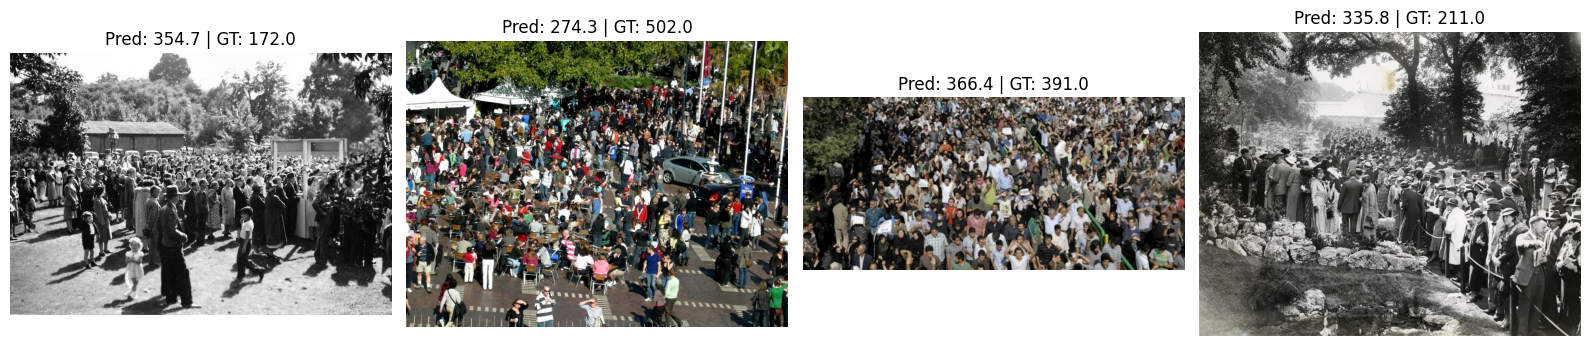

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load best model
model = load_best_model(train_config_shufflenet, device)

# Evaluate MAE
mae = test_model(model, test_loader, device)
print(f"Test MAE: {mae:.2f}")

# Get predictions
preds, gts = predict_on_test_set(model, test_loader, device, max_images=4)
# Print five predictions
# print("Sample Ground Truth:", gts[:5])
# print("Sample predictions:", preds[:5])

# TensorBoard Visualization

In [22]:
import subprocess
import time
import webbrowser

def start_tensorboard(logdir="runs", port=6006):
    """
    Starts TensorBoard as a background process and opens it in your default browser.
    Returns the process handle so you can terminate it later.
    """
    tb_cmd = [
        "tensorboard",
        f"--logdir={logdir}",
        f"--port={port}",
        "--host=localhost"
    ]
    
    # Start the process
    print(f"Starting TensorBoard on port {port}...")
    process = subprocess.Popen(tb_cmd)
    
    # Give it a second to get going
    time.sleep(2)
    
    # Open in browser automatically
    url = f"http://localhost:{port}"
    print(f"Opening {url} in your default browser...")
    webbrowser.open(url)
    
    return process


def stop_tensorboard(process):
    """
    Stops the TensorBoard process started by `start_tensorboard()`.
    """
    print("Stopping TensorBoard...")
    process.terminate()  # or process.kill()

In [23]:
process = start_tensorboard(logdir="runs", port=6009)

Starting TensorBoard on port 6009...


TensorFlow installation not found - running with reduced feature set.

NOTE: Using experimental fast data loading logic. To disable, pass
    "--load_fast=false" and report issues on GitHub. More details:
    https://github.com/tensorflow/tensorboard/issues/4784

E0427 03:07:24.244191 125485682534208 program.py:300] TensorBoard could not bind to port 6009, it was already in use
ERROR: TensorBoard could not bind to port 6009, it was already in use


Opening http://localhost:6009 in your default browser...


In [24]:
# stop_tensorboard(process)
# Uncomment the line below to stop TensorBoard when you're done